<a href="https://colab.research.google.com/github/MMQuants/FMI_diplomna_rabota/blob/main/correlated_datasim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

In [2]:
# Брой алтернативи (напр. инвестиционни проекти)
num_alternatives = 150

# Сценарий: Конфликтни критерии
# Генерираме Базов фактор (напр. "Агресивност" на актива) от 0 до 10
base_factor = np.random.uniform(1, 10, num_alternatives)

In [3]:
# Критерий 1: Доходност (Правопропорционална на базовия фактор + шум)
revenue = 2.5 * base_factor + np.random.normal(0, 1.5, num_alternatives)

# Критерий 2: Риск (Също расте с базовия фактор - силен конфликт с доходността)
risk = 1.8 * base_factor + np.random.normal(0, 1.0, num_alternatives)

# Критерий 3: Ликвидност (Обратнопропорционална на фактора + шум)
liquidity = 100 - (7.0 * base_factor) + np.random.normal(0, 5.0, num_alternatives)

In [4]:
# Всички критерии трябва да бъдат положителни стойности (нормализиране, ако има отрицателни)
revenue = np.clip(revenue, 0.1, None)
risk = np.clip(risk, 0.1, None)
liquidity = np.clip(liquidity, 0.1, None)

# 2. Обединяваме данните в Матрица на решенията (Decision Matrix)
# Редове: Алтернативи (150), Колони: Критерии (3)

decision_matrix = np.column_stack((revenue, risk, liquidity))
print(f"Формат на матрицата с данни: {decision_matrix.shape}")
print("\n Първите 5 симулирани алтернативи (Доходност, Риск, Ликвидност):")
print(decision_matrix[:5])

Формат на матрицата с данни: (150, 3)

 Първите 5 симулирани алтернативи (Доходност, Риск, Ликвидност):
[[10.63861123  7.61498177 71.06554257]
 [24.34339291 15.95378858 29.36256601]
 [18.91779604 15.29071316 54.64014154]
 [14.21679884 10.06812607 55.86288867]
 [ 7.72465363  3.88745749 89.06731157]]


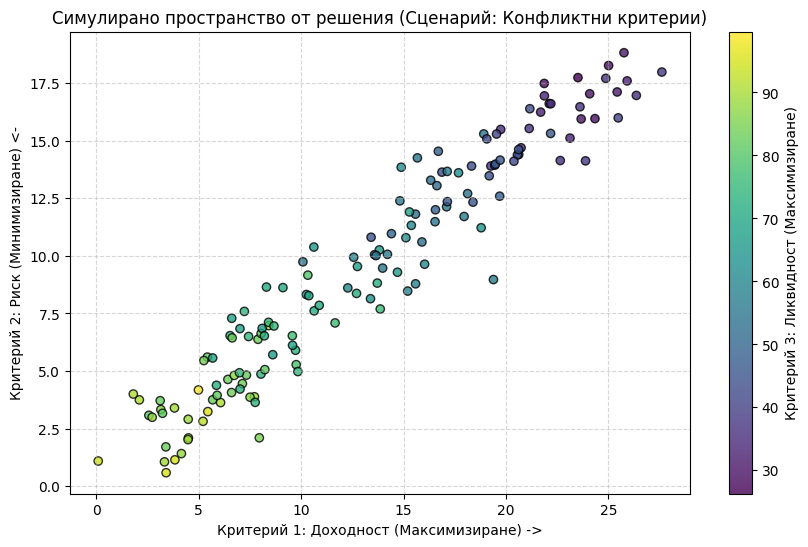

In [5]:
# 3. Визуализация на пространството от решения (Конфликта между Доходност и Риск)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
revenue, risk, c=liquidity, cmap="viridis", edgecolor="k", alpha=0.8 )
plt.title(
"Симулирано пространство от решения (Сценарий: Конфликтни критерии)",
fontsize=12,)
plt.xlabel("Критерий 1: Доходност (Максимизиране) ->")
plt.ylabel("Критерий 2: Риск (Минимизиране) <-")
cbar = plt.colorbar(scatter)
cbar.set_label("Критерий 3: Ликвидност (Максимизиране)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()